## baseline_one: sanity check of model using only basic features, bullet weight and powder charge

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("baseline_zero_data.csv")
df.head(20)

,cartridge,bullet_weight,charge_weight,barrel_length,velocity_fps,twist_rate
0,300_blk,200.0,7.0,9.0,710.0,7.0
1,300_blk,200.0,7.5,9.0,877.0,7.0
2,300_blk,200.0,8.5,9.0,1015.0,7.0
3,300_blk,200.0,9.0,9.0,1080.0,7.0
4,300_blk,200.0,11.0,9.0,904.0,7.0
5,300_blk,200.0,11.5,9.0,945.0,7.0
6,300_blk,200.0,11.5,9.0,925.0,7.0
7,300_blk,200.0,12.0,9.0,905.0,7.0
8,300_blk,200.0,11.0,9.0,823.0,7.0
9,300_blk,200.0,11.5,9.0,890.0,7.0


In [3]:
blk = df[df["cartridge"].isin(["300_blk"])].copy()

In [4]:
len(blk)

38

In [11]:
blk.head(38)

,cartridge,bullet_weight,charge_weight,barrel_length,velocity_fps,twist_rate
0,300_blk,200.0,7.0,9.0,710.0,7.0
1,300_blk,200.0,7.5,9.0,877.0,7.0
2,300_blk,200.0,8.5,9.0,1015.0,7.0
3,300_blk,200.0,9.0,9.0,1080.0,7.0
4,300_blk,200.0,11.0,9.0,904.0,7.0
5,300_blk,200.0,11.5,9.0,945.0,7.0
6,300_blk,200.0,11.5,9.0,925.0,7.0
7,300_blk,200.0,12.0,9.0,905.0,7.0
8,300_blk,200.0,11.0,9.0,823.0,7.0
9,300_blk,200.0,11.5,9.0,890.0,7.0


In [6]:
features = ["charge_weight", "bullet_weight"]
target = ["velocity_fps"]
X = blk[features].astype(float)
y = blk[target].astype(float)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
coeffs = pd.Series(model.coef_.ravel(), index=features)
intercept = model.intercept_
coeffs, intercept


(charge_weight    83.064630
 bullet_weight    -5.296148
 dtype: float64,
 array([1184.72400652]))

### Sanity check passed: increasing charge_weight increases velocity, increasing bullet_weight decreases velocity

In [12]:
from sklearn.metrics import mean_absolute_error

# Baseline-zero MAE for .300 BLK only
mean_pred = np.full_like(y, y.mean())
mae_zero = mean_absolute_error(y, mean_pred)

# Baseline-1 MAE
preds = model.predict(X)
mae_one = mean_absolute_error(y, preds)

mae_zero, mae_one


(425.1191135734071, 91.11922656817119)

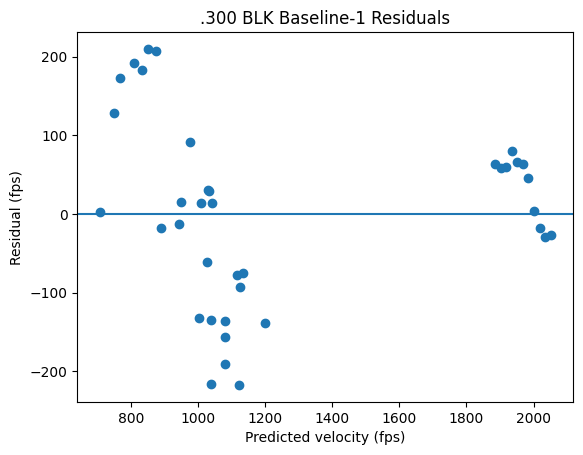

In [13]:
import matplotlib.pyplot as plt

residuals = y - preds

plt.scatter(preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted velocity (fps)")
plt.ylabel("Residual (fps)")
plt.title(".300 BLK Baseline-1 Residuals")
plt.show()


### Interpretation: model seems good so far
- mae_one is better than mae_zero (ingorance)
- numbers are moving in the correct direction (increasing powder increases velocity, increasing bullet mass decreases velocity)
- residual graph shows noise, no obvious structure